# Coffee Bean Dataset: Model Training

In this notebook, we train a deep learning model using the preprocessed dataset created in the preprocessing notebook.

We use:
- A pretrained ResNet18 model (transfer learning)
- Frozen feature extractor (to reduce computation)
- Only the final classification layer is trained

This ensures efficient training on limited hardware while leveraging learned visual features from ImageNet.

1. Load your preprocessed splits

In [31]:
import pickle

with open("coffee_splits.pkl", "rb") as f:
    X_train, X_val, y_train, y_val = pickle.load(f)

print(len(X_train), len(X_val))

955 239


We load the preprocessed dataset containing:
- image file paths
- class labels
- train/validation split

No additional preprocessing is required here.

2. Encode labels

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

3. Dataset class

In [33]:
from torch.utils.data import Dataset
from PIL import Image

class CoffeeDataset(Dataset):
    def __init__(self, paths, labels, transform, label_encoder):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.le = label_encoder

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.le.transform([self.labels[idx]])[0]

        img = self.transform(img)
        return img, label

4. Transforms

In [34]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

5. DataLoaders

In [35]:
from torch.utils.data import DataLoader

train_dataset = CoffeeDataset(X_train, y_train, train_transform, le)
val_dataset = CoffeeDataset(X_val, y_val, val_transform, le)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

We use ResNet18 pretrained on ImageNet.

Why:
- Lightweight and fast (important for limited hardware)
- Strong feature extractor for small datasets
- Works well with 224x224 images

6. Load pretrained model

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# replace classifier
model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)

7. Loss + optimizer

In [37]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

8. Training loop

In [38]:
def train_model(model, train_loader, val_loader, epochs=10):

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = correct / total

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.3f} | Val Acc: {acc:.3f}")

9. Train model

In [39]:
train_model(model, train_loader, val_loader, epochs=10)

Epoch 1/10 | Loss: 32.827 | Val Acc: 0.812
Epoch 2/10 | Loss: 22.125 | Val Acc: 0.904
Epoch 3/10 | Loss: 17.564 | Val Acc: 0.900
Epoch 4/10 | Loss: 15.063 | Val Acc: 0.941
Epoch 5/10 | Loss: 13.499 | Val Acc: 0.912
Epoch 6/10 | Loss: 12.164 | Val Acc: 0.937
Epoch 7/10 | Loss: 10.979 | Val Acc: 0.946
Epoch 8/10 | Loss: 10.504 | Val Acc: 0.950
Epoch 9/10 | Loss: 9.911 | Val Acc: 0.946
Epoch 10/10 | Loss: 9.649 | Val Acc: 0.954


10. Evaluation (confusion matrix)

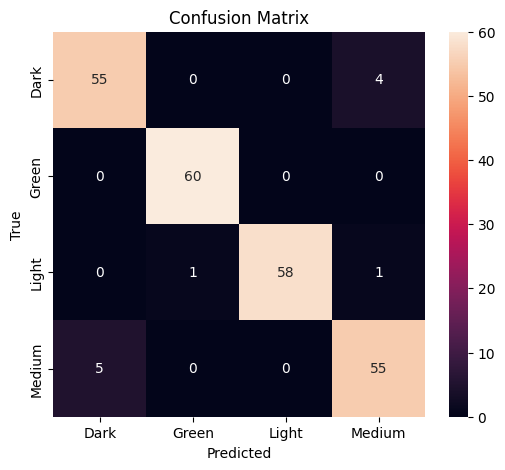

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Results: Confusion Matrix
- What we did: After training the CNN, we evaluated it on the test set and plotted a confusion matrix to see exactly where the model is getting predictions right and where it's making mistakes.
- Result:
| True \ Predicted | Dark | Green | Light | Medium |
|-----------------|------|-------|-------|--------|
| **Dark**        | 55   | 0     | 0     | 4      |
| **Green**       | 0    | 60    | 0     | 0      |
| **Light**       | 0    | 1     | 58    | 1      |
| **Medium**      | 5    | 0     | 0     | 55     |

Interpretation: This is a strong result for a first training run. The model classifies the vast majority of images correctly, with only 11 misclassifications out of 233 total test images. A few observations worth noting:

1. Green is classified perfectly (60/60); consistent with what PCA already suggested, green beans are visually the most distinct class
2. The main source of confusion is between Dark and Medium: 4 Dark beans were predicted as Medium, and 5 Medium beans were predicted as Dark. This makes intuitive sense: these two roast levels are the most visually similar, both appearing as dark brown beans with subtle differences in shade
3. Light is nearly perfect (58/60), with only 2 minor misclassifications spread across Green and Medium

The confusion is concentrated exactly where we'd expect it (between adjacent roast levels) rather than being random noise. This suggests the model has genuinely learned the roast level spectrum rather than memorizing patterns.

---

# Reflection: What the Results Tell Us & Where to Go Next
The confusion matrix from the first training run is actually more informative than just an accuracy score. Looking at it carefully, a clear pattern emerges:

Green and Light are nearly perfectly classified / these classes have strong, distinct visual signals that the CNN picked up on immediately
The only real confusion is between Dark and Medium / and this isn't random noise, it reflects a genuine real-world problem: dark and medium roast beans exist on a continuous spectrum, not as two cleanly separated categories

This is an important insight. The model isn't failing arbitrarily. It's failing exactly where a human might also struggle. Dark and medium roast beans are genuinely similar in appearance, and treating them as two discrete, unrelated labels is arguably an oversimplification of reality.
This is what motivates the next step. Rather than just tuning hyperparameters to squeeze out a few more percentage points of accuracy, a more meaningful direction is to shift from pure classification toward semantic representation learning.
The idea is that coffee roast levels and their associated taste profiles (fruity/floral/acidic for light, balanced/nutty/sweet for medium, bitter/smoky/chocolatey for dark) exist in a continuous semantic space. A model that understands this space would naturally place Dark and Medium close together, rather than treating a wrong prediction between them the same as predicting Green instead of Dark.
To achieve this, the plan is to introduce two types of embeddings into the pipeline:

1. Image embeddings - instead of only using the final classification layer, we extract the CNN's internal 512-dimensional feature vector. This gives us a rich visual representation of each bean that captures more than just its class label.
2. Text embeddings - the taste profiles defined for each roast level can be encoded into vectors using Sentence-BERT. This gives us a semantic representation of what each roast level tastes like.

The goal is then to align these two embedding spaces so that visually similar beans end up close to semantically similar taste profiles. This is a more honest model of the problem, and it opens the door to richer outputs than a simple 4-class prediction.

---

# Addings embeddings

In [45]:
#Freeze trained model
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

2. Modify model to output embeddings

In [46]:
import torch
import torchvision.models as models

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()  # <-- turns model into feature extractor

resnet = resnet.to(device)
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Now output is: 512-dimensional image embedding per image

---

# Extract image embeddings

In [47]:
def extract_embeddings(loader, model):
    embeddings = []
    labels = []

    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)

            feats = model(images)   # [batch, 512]

            embeddings.append(feats.cpu())
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)

In [48]:
train_emb, train_labels = extract_embeddings(train_loader, resnet)
val_emb, val_labels = extract_embeddings(val_loader, resnet)

1. Define your TEXT embeddings

In [ ]:
#pip install sentence-transformers

Define taste profile:

In [49]:
taste_profiles = {
    "Light": "fruity, floral, acidic, bright",
    "Medium": "balanced, nutty, sweet",
    "Dark": "bitter, smoky, chocolatey"
}

Convert to embeddings:

In [50]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer('all-MiniLM-L6-v2')

text_embeddings = {
    k: text_model.encode(v) for k, v in taste_profiles.items()
}

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\raozg\DataspellProjects\SoyMilkCapuccino\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raozg\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

- Image space → 512D CNN vectors
- Text space → 384D SBERT vectors

# embedding visualization

In [55]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

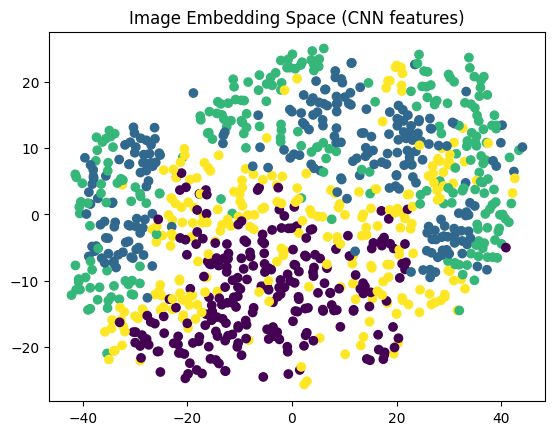

In [56]:
all_emb = train_emb.numpy()
labels = train_labels.numpy()

tsne = TSNE(n_components=2)
proj = tsne.fit_transform(all_emb)

plt.scatter(proj[:,0], proj[:,1], c=labels)
plt.title("Image Embedding Space (CNN features)")
plt.show()

MESSING AROUND FROM THIS POINT FORWARD

---

In [85]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import pickle
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
import random
import matplotlib.pyplot as plt

In [86]:
with open("coffee_splits.pkl", "rb") as f:
    X_train, X_val, y_train, y_val = pickle.load(f)

In [87]:
le = LabelEncoder()
le.fit(y_train)

class_names = le.classes_
num_classes = len(class_names)

In [88]:
taste_profiles = {
    "Dark": "bitter, smoky, chocolatey",
    "Medium": "balanced, nutty, sweet",
    "Light": "fruity, floral, acidic, bright",
    "Green": "raw, grassy, vegetal"
}

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze backbone
for p in model.parameters():
    p.requires_grad = False

# classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

In [96]:
MODEL_PATH = "coffee_model.pth"

try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("Model loaded successfully")
except FileNotFoundError:
    print("No saved model found — using fresh weights")

No saved model found — using fresh weights


In [97]:
text_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [98]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [99]:
def predict_image(image_path):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    label = class_names[pred_idx]
    profile = taste_profiles[label]

    return img, label, profile, confidence

In [100]:
def show_result(image_path):
    img, label, profile, conf = predict_image(image_path)

    plt.imshow(img)
    plt.axis("off")

    plt.title(f"{label} ({conf:.2f})\n{profile}")
    plt.show()

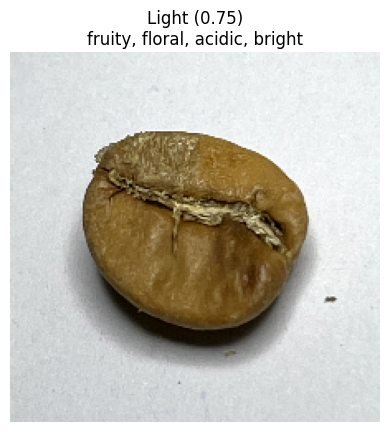

In [129]:
sample = random.choice(X_val)
show_result(sample)

Wanna visually validate not all beans are classed as light.

In [156]:
import matplotlib.pyplot as plt
import random

def show_batch_with_embeddings(paths, n=6):
    samples = random.sample(paths, n)

    plt.figure(figsize=(15, 8))

    for i, path in enumerate(samples):
        img, label, profile, conf, emb = predict_with_embedding(path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")

        # compact embedding preview
        emb_preview = emb[:5].round(2)

        plt.title(
            f"{label} ({conf:.2f})\n{profile}\nemb: {emb_preview}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

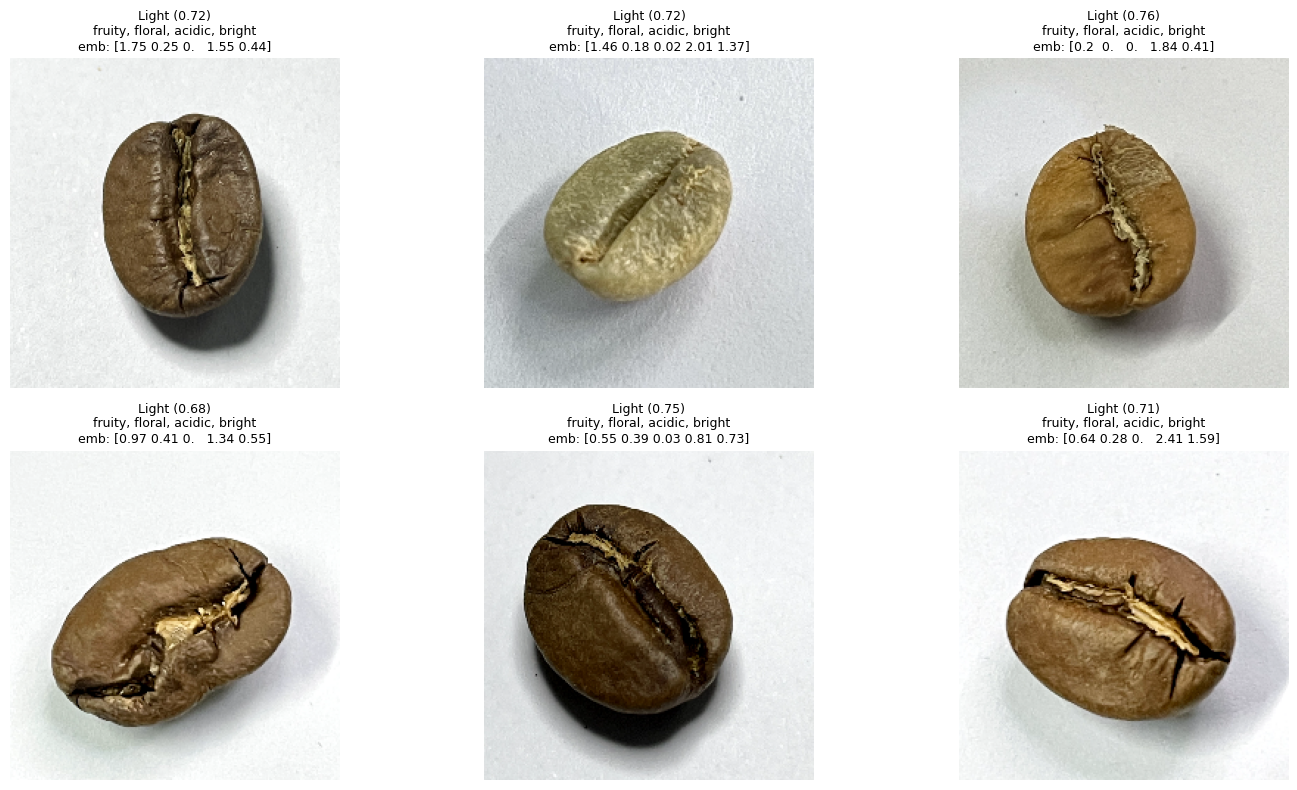

In [157]:
show_batch_with_embeddings(X_val, n=6)

All beans are classed as light and embedded as fruity,floral,acidic and bright.